In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
import pmdarima as pm
import lightgbm as lgb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib

import TS_utils as utils
import prepTCN

# Data load

In [3]:
df = pd.read_csv(r"../datasets/taxi_pickups_area.csv")
df[df.columns.difference(["Trip Start Timestamp"])] = df[df.columns.difference(["Trip Start Timestamp"])].astype("int16")

# Feature creation

In [11]:
df_time_feature = utils.build_time_features(df)

In [12]:
X_cols = ['Trip Start Timestamp', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6',
       'fourier_sin_1', 'fourier_cos_1',
       'fourier_sin_2', 'fourier_cos_2']

In [13]:
lag_list = [1, 2, 3, 4, 96]          # 1–4 шага и сутки назад
window_list = [4, 16, 96]            # час, 4 часа, сутки
agg_funcs = {
    "median": np.median,
    "std": np.std,
}

df_long = utils.build_ar_ma_features(
    df=df,                   
    timestamp_col="Trip Start Timestamp",
    lag_list=lag_list,
    window_list=window_list,
    agg_funcs=agg_funcs,
)

In [14]:
df_long_time = df_long.merge(df_time_feature[X_cols])

In [15]:
df_long_time['area'] = df_long_time['area'].astype('category')

# Data split

In [16]:
horizon = 673
n = df.shape[0]

date_col = "Trip Start Timestamp"
area_cols = df.columns.drop(date_col)
target_col = "target"

df_long_time[date_col] = pd.to_datetime(df_long_time[date_col])

unique_ts = np.sort(df_long_time[date_col].unique())

test_start_ts = unique_ts[-horizon]              # начало test
val_start_ts  = unique_ts[-2 * horizon]          # начало val

test = df_long_time[df_long_time[date_col] >= test_start_ts].copy()

val = df_long_time[
    (df_long_time[date_col] >= val_start_ts) &
    (df_long_time[date_col] < test_start_ts)
].copy()

train = df_long_time[df_long_time[date_col] < val_start_ts].copy()

n_val = len(val)

In [17]:
df_long_time.columns.difference(['target'])

Index(['Trip Start Timestamp', 'area', 'dow_1', 'dow_2', 'dow_3', 'dow_4',
       'dow_5', 'dow_6', 'fourier_cos_1', 'fourier_cos_2', 'fourier_sin_1',
       'fourier_sin_2', 'roll_median_16', 'roll_median_4', 'roll_median_96',
       'roll_std_16', 'roll_std_4', 'roll_std_96', 'y_lag_1', 'y_lag_2',
       'y_lag_3', 'y_lag_4', 'y_lag_96'],
      dtype='object')

In [18]:
feature_cols = df_long_time.columns.difference([date_col, target_col])

X_train = train[feature_cols]
y_train = train[target_col]

X_val = val[feature_cols]
y_val = val[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

# Classical machine learning
## lgb model

In [19]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val, label=y_val, reference=lgb_train)
params = {
    "objective": "regression",
    "metric": "mae",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "verbose": -1,
    "seed": 42,
}

lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=100,
    valid_sets=[lgb_train, lgb_val],
    valid_names=["train", "val"]
)

y_val_pred_lgb = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
mae_val_lgb = mean_absolute_error(y_val, y_val_pred_lgb)
print("LightGBM MAE on validation:", mae_val_lgb)

LightGBM MAE on validation: 0.31870837128335866


In [ ]:
pred_by_area = val[[date_col, target_col, "area"]].copy()
pred_by_area['pred'] = y_val_pred_lgb

mae_by_area = (
    pred_by_area
    .groupby("area", observed=True)[["area","target", "pred"]]
    .apply(lambda g: mean_absolute_error(g["target"], g["pred"]))
    .reset_index(name="MAE_val")
)

                        area   MAE_val
76   Pickup Community Area_8  3.417022
26  Pickup Community Area_32  2.854267
74  Pickup Community Area_76  1.819799
21  Pickup Community Area_28  1.795654
0    Pickup Community Area_0  1.640649


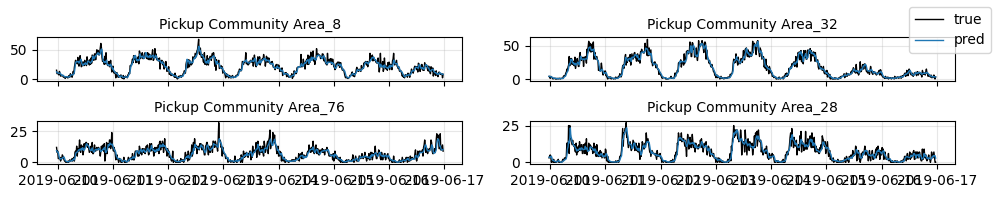

In [63]:
print(mae_by_area.sort_values(by = 'MAE_val', ascending=False).head())
utils.plot_true_vs_pred_subplots(pred_by_area.pivot(index=date_col, columns='area', values='target'), pred_by_area.pivot(index=date_col, columns='area', values='pred'), 
                                 mae_by_area.sort_values(by = 'MAE_val',ascending=False)[:4]['area'].to_list(), figsize=(10, 2))

In [21]:
joblib.dump(lgb_model, "models/lgbm_regressor.pkl")

['models/lgbm_regressor.pkl']

# Deep Learning algorithms for sequences
## Temporal Convolutional Network

In [8]:
result = prepTCN.prepare_and_train_tcn_pipeline(
    df=df,
    timestamp_col="Trip Start Timestamp",
    horizon=673,
    context_len=673,   # неделя
    bs=256,
    epochs=5,
    lr=1e-3,
    seed=42
)

epoch,train_loss,valid_loss,mae,time
0,1.001429,0.153398,0.131450,32:47
1,0.928613,0.155799,0.126579,31:40
2,0.926835,0.158869,0.124322,31:22
3,0.942497,0.154533,0.148740,32:29
4,0.859302,0.153901,0.145637,32:06


In [11]:
prepTCN.save_tcn_artifacts(result, base_path="models/tcn_artifacts_v1")

Артефакты TCN сохранены в /home/alagis/S21/DS_projects/DS5_Uber.ID_886384-1/src/models/tcn_artifacts_v1


In [4]:
result = prepTCN.load_tcn_artifacts("models/tcn_artifacts_v1")

Артефакты TCN загружены из /home/alagis/S21/DS_projects/DS5_Uber.ID_886384-1/src/models/tcn_artifacts_v1


mean MAE over all areas: 0.599
                       area    MAE_val
0  Pickup Community Area_32  11.169547
1   Pickup Community Area_8   9.482492
2  Pickup Community Area_28   4.449654
3   Pickup Community Area_0   3.927245
4  Pickup Community Area_76   3.680819


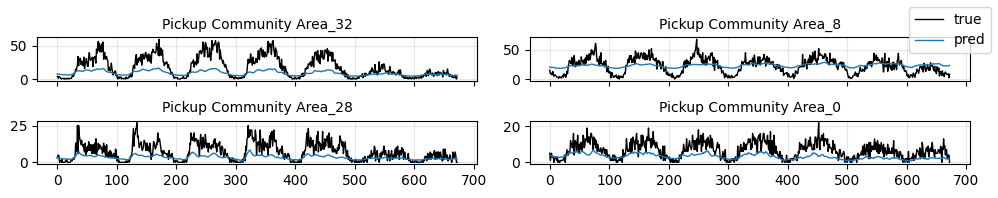

In [10]:
tcn_info_df = result["tcn_info_df"]
val_true_df = result["val_true_df"]
val_pred_df = result["val_pred_df"]
area_cols = result["area_cols"]

print("mean MAE over all areas:", round(np.mean(tcn_info_df["MAE_val"]),3))
print(tcn_info_df.sort_values(by = 'MAE_val', ascending=False).head())
utils.plot_true_vs_pred_subplots(
    y_val_true=val_true_df,
    y_val_pred=val_pred_df,
    areas=tcn_info_df.sort_values("MAE_val", ascending=False).head(4)["area"].tolist(),
    figsize=(10, 2)
)

# Check best model on test dataset and save

In [23]:
y_test_pred_lgb = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)
mae_test_lgb = mean_absolute_error(y_test, y_test_pred_lgb)
print("LightGBM MAE on test:", mae_test_lgb)

LightGBM MAE on test: 0.3201482024589023


In [24]:
pred_by_area = test[[date_col, target_col, "area"]].copy()
pred_by_area['pred'] = y_test_pred_lgb

mae_by_area = (
    pred_by_area
    .groupby("area", observed=True)[["area","target", "pred"]]
    .apply(lambda g: mean_absolute_error(g["target"], g["pred"]))
    .reset_index(name="MAE_val")
)

                        area   MAE_val
76   Pickup Community Area_8  3.148871
26  Pickup Community Area_32  2.746881
74  Pickup Community Area_76  1.865600
21  Pickup Community Area_28  1.844228
0    Pickup Community Area_0  1.671195


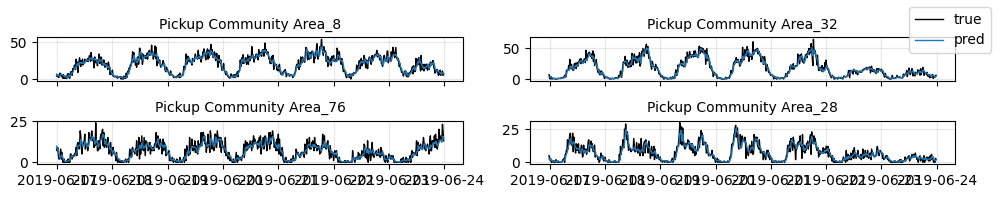

In [25]:
print(mae_by_area.sort_values(by = 'MAE_val', ascending=False).head())
utils.plot_true_vs_pred_subplots(pred_by_area.pivot(index=date_col, columns='area', values='target'), pred_by_area.pivot(index=date_col, columns='area', values='pred'), 
                                 mae_by_area.sort_values(by = 'MAE_val',ascending=False)[:4]['area'].to_list(), figsize=(10, 2))

In [26]:
pred_by_area

,Trip Start Timestamp,target,area,pred
7295,2019-06-16 23:45:00,2,Pickup Community Area_0,3.128083
7296,2019-06-17 00:00:00,6,Pickup Community Area_0,3.739439
7297,2019-06-17 00:15:00,3,Pickup Community Area_0,2.932593
7298,2019-06-17 00:30:00,4,Pickup Community Area_0,3.391755
7299,2019-06-17 00:45:00,1,Pickup Community Area_0,3.562339
...,...,...,...,...
621499,2019-06-23 22:45:00,0,Pickup Community Area_77,0.241723
621500,2019-06-23 23:00:00,0,Pickup Community Area_77,0.241723
621501,2019-06-23 23:15:00,0,Pickup Community Area_77,0.075581
621502,2019-06-23 23:30:00,0,Pickup Community Area_77,0.075581


In [27]:
pred_by_area.to_csv("data/taxi_submission_file.csv")